<a href="https://colab.research.google.com/github/yash25raj/ML/blob/main/Kinetex_Heart_Disease.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Importing libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import  StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,roc_curve
from sklearn.model_selection import GridSearchCV

In [ ]:
# Loading the dataset
df = pd.read_csv('heart_disease_data.csv')

In [ ]:
# Display the first few rows
print("First 5 rows of the dataset:")
print(df.head())

First 5 rows of the dataset:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    0   0       120   354    0        1      163      1      0.6      2   

   ca  thal  target  
0   0     1       1  
1   0     2       1  
2   0     2       1  
3   0     2       1  
4   0     2       1  


In [ ]:
# Display dataset information
print("\nDataset Info:")
df.info()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [ ]:
# Perform descriptive statistical analysis
print("\nDescriptive Statistics:")
print(df.describe())


Descriptive Statistics:
              age         sex          cp    trestbps        chol         fbs  \
count  303.000000  303.000000  303.000000  303.000000  303.000000  303.000000   
mean    54.366337    0.683168    0.966997  131.623762  246.264026    0.148515   
std      9.082101    0.466011    1.032052   17.538143   51.830751    0.356198   
min     29.000000    0.000000    0.000000   94.000000  126.000000    0.000000   
25%     47.500000    0.000000    0.000000  120.000000  211.000000    0.000000   
50%     55.000000    1.000000    1.000000  130.000000  240.000000    0.000000   
75%     61.000000    1.000000    2.000000  140.000000  274.500000    0.000000   
max     77.000000    1.000000    3.000000  200.000000  564.000000    1.000000   

          restecg     thalach       exang     oldpeak       slope          ca  \
count  303.000000  303.000000  303.000000  303.000000  303.000000  303.000000   
mean     0.528053  149.646865    0.326733    1.039604    1.399340    0.729373   
st

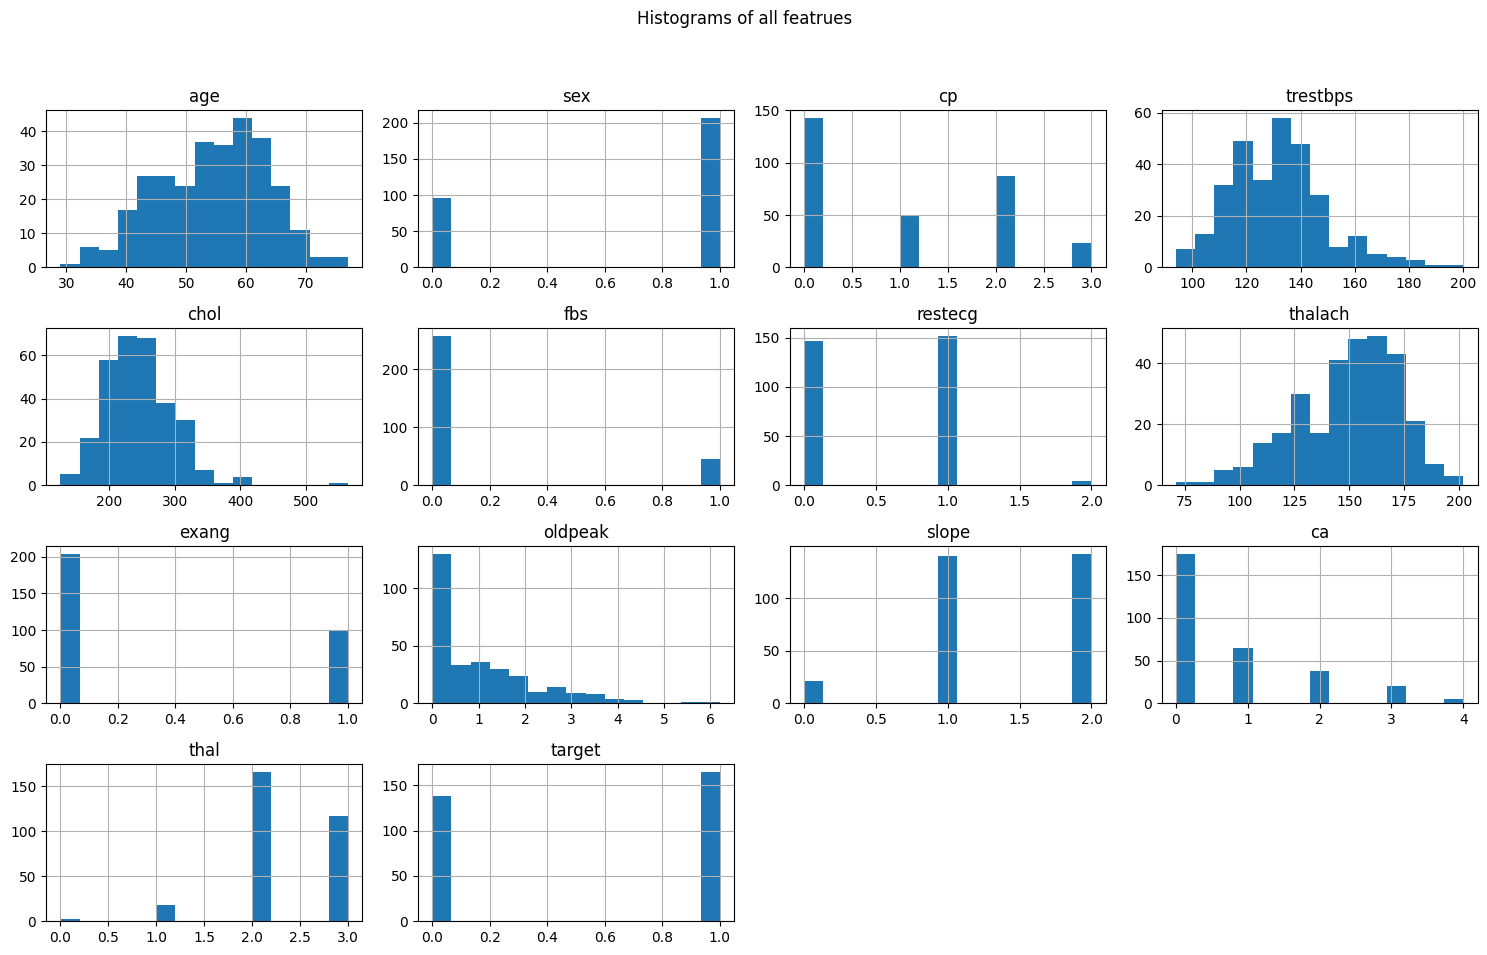

In [ ]:
# Create histograms for numerical features
df.hist(bins=15, figsize=(15,10))
plt.suptitle('Histograms of all featrues')
plt.tight_layout(rect=[0,0.03,1,0.95])
plt.show()

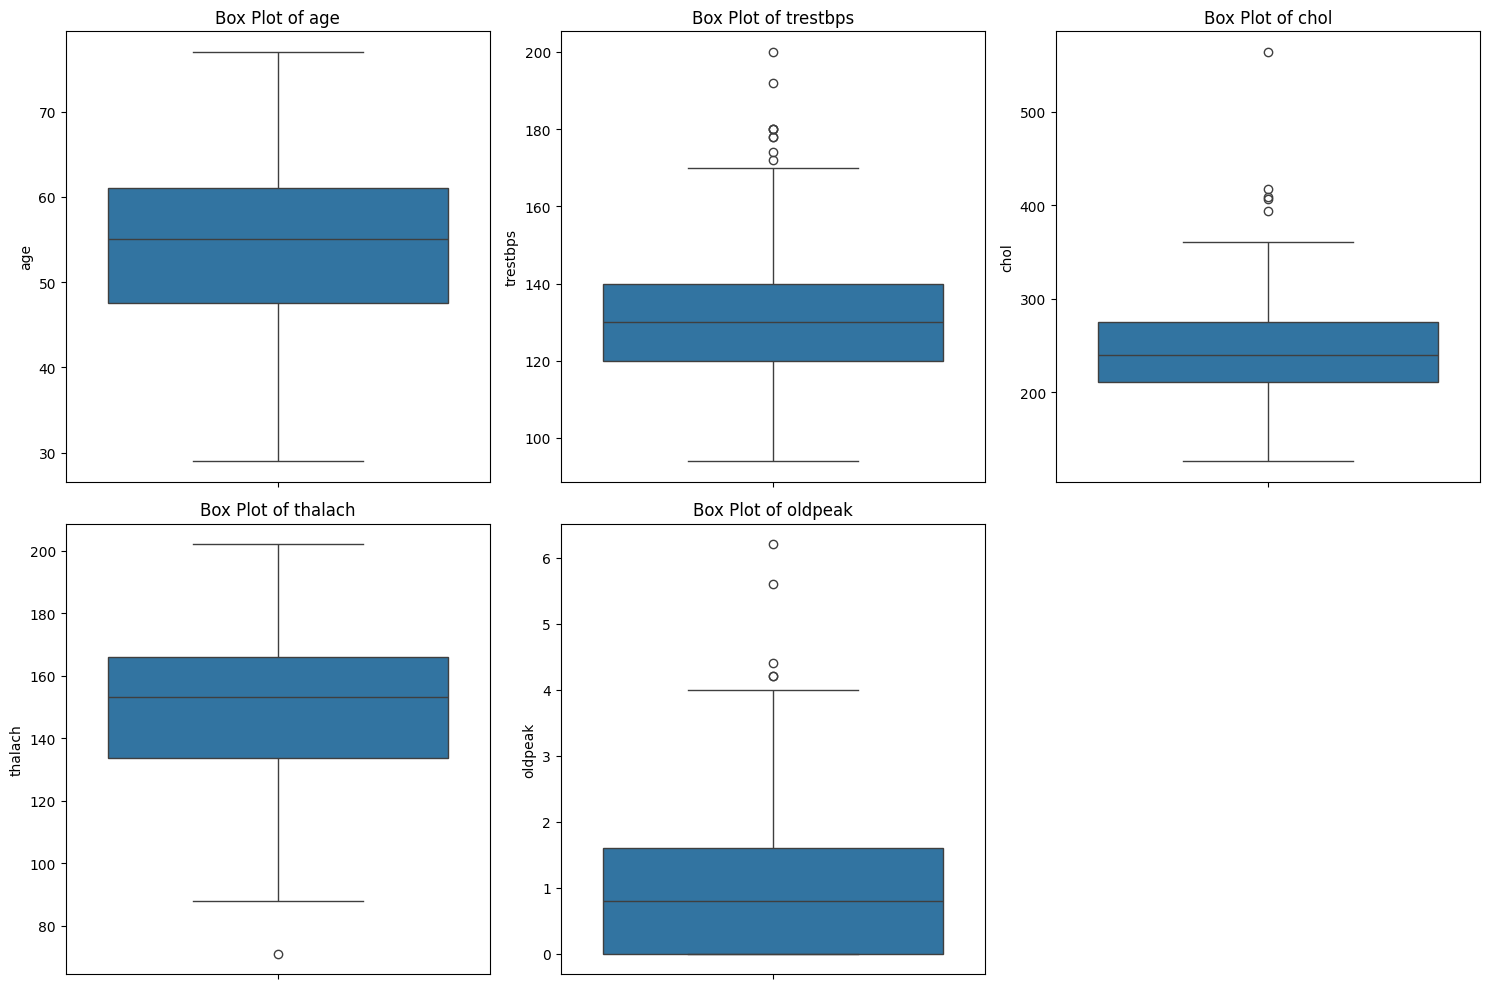

In [ ]:
# Create box plots for numerical features
plt.figure(figsize=(15,10))
for i, column in enumerate(['age','trestbps','chol','thalach','oldpeak']):
  plt.subplot(2,3,i+1)
  sns.boxplot(y=df[column])
  plt.title(f'Box Plot of {column}')

plt.tight_layout()
plt.show()

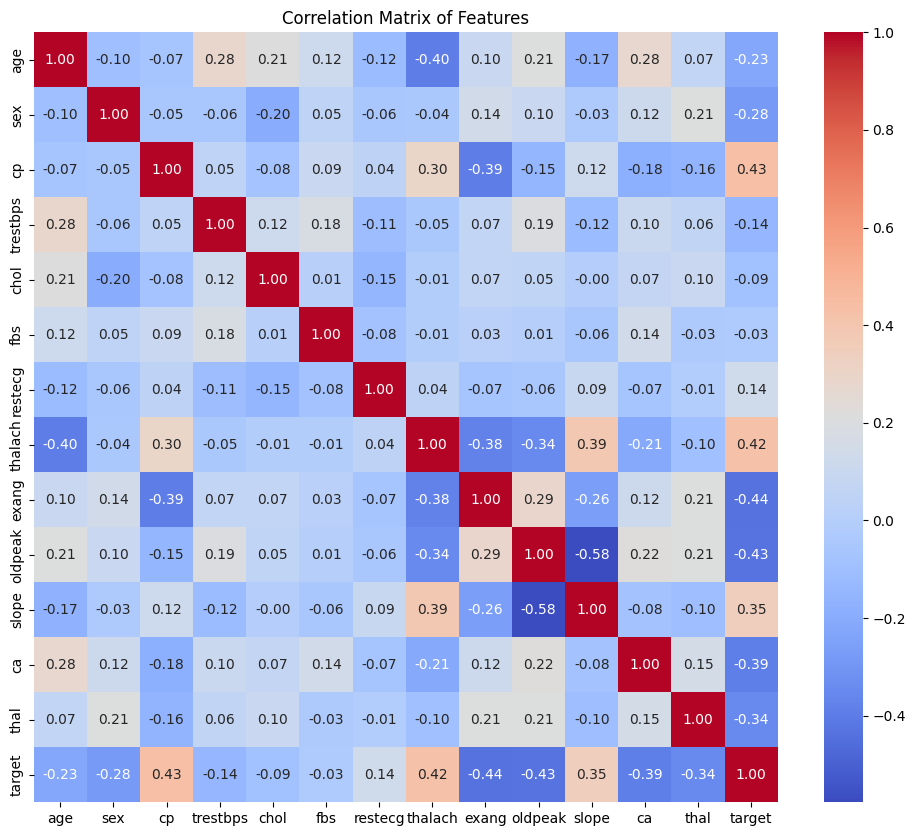

In [ ]:
# Create a correlation matrix
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm',fmt='.2f')
plt.title('Correlation Matrix of Features')
plt.show()

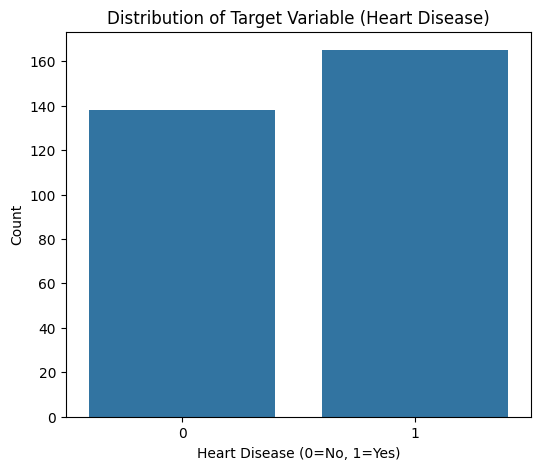


Distribution of the target variable:
target
1    165
0    138
Name: count, dtype: int64

Percentage of the target variable:
target
1    54.455446
0    45.544554
Name: proportion, dtype: float64


In [ ]:
# Analyze the balance of the 'target' variable
plt.figure(figsize=(6,5))
sns.countplot(x=df['target'])
plt.title('Distribution of Target Variable (Heart Disease)')
plt.xlabel('Heart Disease (0=No, 1=Yes)')
plt.ylabel('Count')
plt.show()

print('\nDistribution of the target variable:')
print(df['target'].value_counts())
print('\nPercentage of the target variable:')
print(df['target'].value_counts(normalize=True) * 100)

In [ ]:
# Check for missing values
print("\nMissing values in each column:")
print(df.isnull().sum())


Missing values in each column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [ ]:
# Define categorical and numerical features
categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
numerical_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
target = 'target'

# Create copies to avoid modifying the original dataframe directly
data = df.copy()

# One-hot encode categorical features
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoded_features = encoder.fit_transform(data[categorical_features])
encoded_feature_names = encoder.get_feature_names_out(categorical_features)
encoded_df = pd.DataFrame(encoded_features, columns=encoded_feature_names, index=data.index)

# Combine encoded categorical features with numerical features
X = pd.concat([data[numerical_features], encoded_df], axis=1)
y = data[target]

# Scale numerical features
scaler = StandardScaler()
X[numerical_features] = scaler.fit_transform(X[numerical_features])

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("\nShape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)
print("\nFirst 5 rows of preprocessed X_train:")
print(X_train.head())


Shape of X_train: (242, 30)
Shape of X_test: (61, 30)
Shape of y_train: (242,)
Shape of y_test: (61,)

First 5 rows of preprocessed X_train:
          age  trestbps      chol   thalach   oldpeak  sex_0  sex_1  cp_0  \
19   1.613930  0.478391 -0.140381  0.059173  0.655990    1.0    0.0   0.0   
247  1.283063  1.620649 -0.005102 -1.296472 -0.896862    0.0    1.0   0.0   
289  0.069886 -0.206964 -0.797447 -0.859167  0.828529    1.0    0.0   1.0   
288  0.290464 -1.234996  1.714865 -0.290671  1.691225    0.0    1.0   1.0   
60   1.834507 -1.234996  0.362082 -0.859167 -0.896862    1.0    0.0   0.0   

     cp_1  cp_2  ...  slope_2  ca_0  ca_1  ca_2  ca_3  ca_4  thal_0  thal_1  \
19    0.0   0.0  ...      1.0   0.0   0.0   1.0   0.0   0.0     0.0     0.0   
247   1.0   0.0  ...      0.0   0.0   0.0   0.0   1.0   0.0     0.0     1.0   
289   0.0   0.0  ...      0.0   0.0   1.0   0.0   0.0   0.0     0.0     0.0   
288   0.0   0.0  ...      0.0   0.0   1.0   0.0   0.0   0.0     0.0     0.0   



--- Logistic Regression Results ---
Accuracy: 0.8689
Precision: 0.8571
Recall: 0.9091
F1-Score: 0.8824
AUC-ROC: 0.9102


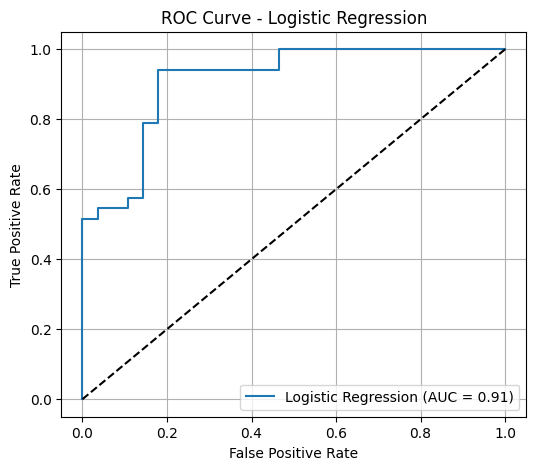

In [ ]:
# Function to train and evaluate models
def train_and_evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc_roc = roc_auc_score(y_test, y_proba)

    print(f"\n--- {model_name} Results ---")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"AUC-ROC: {auc_roc:.4f}")

    # Plot ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc_roc:.2f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - {model_name}')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()

    return {'model': model, 'accuracy': accuracy, 'precision': precision, 'recall': recall, 'f1': f1, 'auc_roc': auc_roc}

# 1. Baseline Logistic Regression model
lr_model = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' is good for small datasets
lr_results = train_and_evaluate_model(lr_model, X_train, y_train, X_test, y_test, "Logistic Regression")


--- Random Forest Results ---
Accuracy: 0.8197
Precision: 0.7750
Recall: 0.9394
F1-Score: 0.8493
AUC-ROC: 0.9210


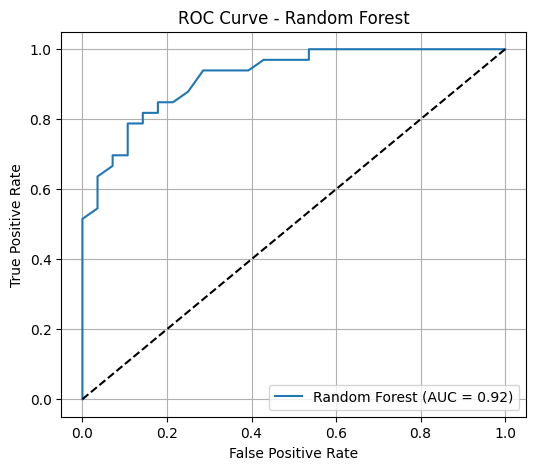

In [ ]:
# 2. Random Forest Classifier
rf_model = RandomForestClassifier(random_state=42)
rf_results = train_and_evaluate_model(rf_model, X_train, y_train, X_test, y_test, "Random Forest")


--- Gradient Boosting Results ---
Accuracy: 0.8033
Precision: 0.8000
Recall: 0.8485
F1-Score: 0.8235
AUC-ROC: 0.8842


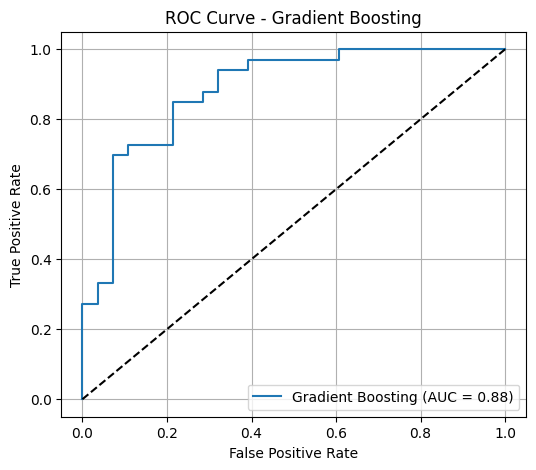

In [ ]:
# 3. Gradient Boosting Classifier
gb_model = GradientBoostingClassifier(random_state=42)
gb_results = train_and_evaluate_model(gb_model, X_train, y_train, X_test, y_test, "Gradient Boosting")

In [ ]:
# Summarize results
all_results = [lr_results, rf_results, gb_results]
results_df = pd.DataFrame([{
    'Model': res['model'].__class__.__name__,
    'Accuracy': res['accuracy'],
    'Precision': res['precision'],
    'Recall': res['recall'],
    'F1-Score': res['f1'],
    'AUC-ROC': res['auc_roc']
} for res in all_results])

print("\n--- Model Comparison ---")
print(results_df.round(4))


--- Model Comparison ---
                        Model  Accuracy  Precision  Recall  F1-Score  AUC-ROC
0          LogisticRegression    0.8689     0.8571  0.9091    0.8824   0.9102
1      RandomForestClassifier    0.8197     0.7750  0.9394    0.8493   0.9210
2  GradientBoostingClassifier    0.8033     0.8000  0.8485    0.8235   0.8842
